# Modular Plotting

Plotting in HiCONA is based on `coolbox`, a package which allows to create and combine custom genomic tracks for chromatin conformation data. HiCONA provides its custom tracks for modular plotting, illustrated below, but also provides some predefined combinations of tracks which should cover the most common cases (see the **Default Plotting** notebook). For flexibility and customization use the individual tracks, for speed and convenience use the presets.

In [1]:
import coolbox.api as ca
import hicona as hi
import hicona.plotting.coolbox_api as ha
import matplotlib as mpl

TABLE_PATH = "../data/IMR90_chr17_clustered_table/"
REGION = "chr17:0-10000000"

table = hi.PixelTable.load(TABLE_PATH)

All tracks provided by HiCONA are stored in the `plotting.coolbox_api` submodule and are divided into pixel tracks, bin tracks and compatibility tracks. The examples below are meant to show what they look like and their usage; to learn how the `coolbox` API works, please refer directly to the [documentation](https://gangcaolab.github.io/CoolBox/index.html#welcome-to-coolbox-s-documentation) of the package.

## Pixel Tracks

The main track added by HiCONA is the `PixelTrack` which, like all tracks which plot pixels, inherits from `HicMatBase`. This class implements the `fetch_data` method in order to be able to retrieve data from a `PixelTable`, while `plot` is the same from the parent class. To initialize the class, simply provide a `PixelTable` instance and the column from which you want to extract the values.

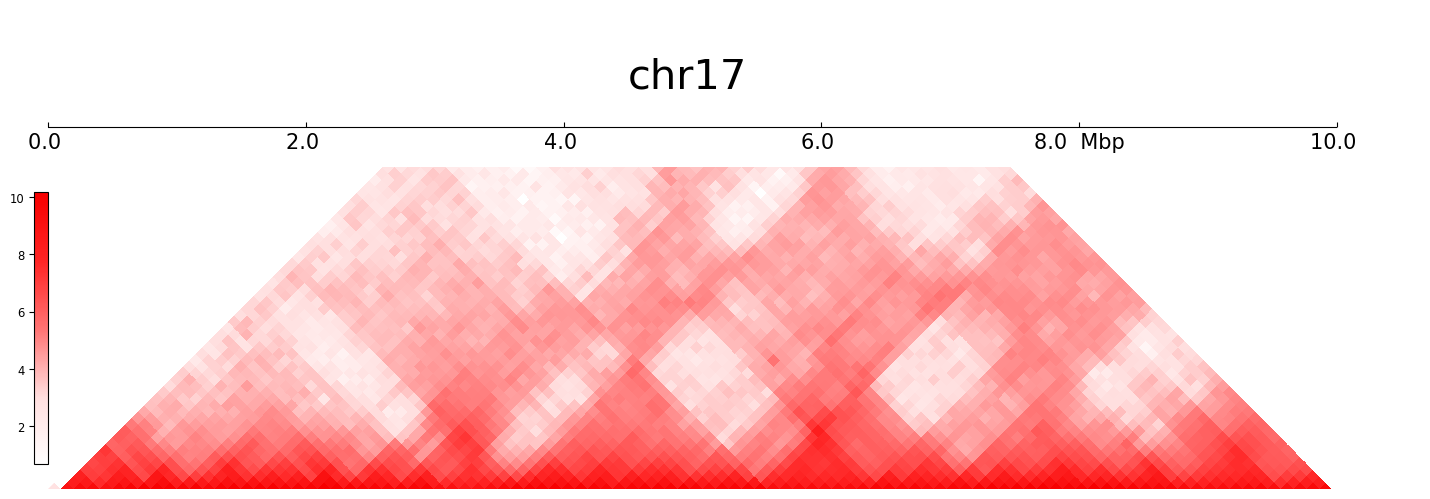

In [2]:
frame = ca.ChromName(fontsize=30) + ca.XAxis() + ha.PixelTrack(table, value_col="count")
frame.goto(REGION)
frame.show()

Since it is an instance of `HicMatBase`, this track can be customized passing other keyword arguments.

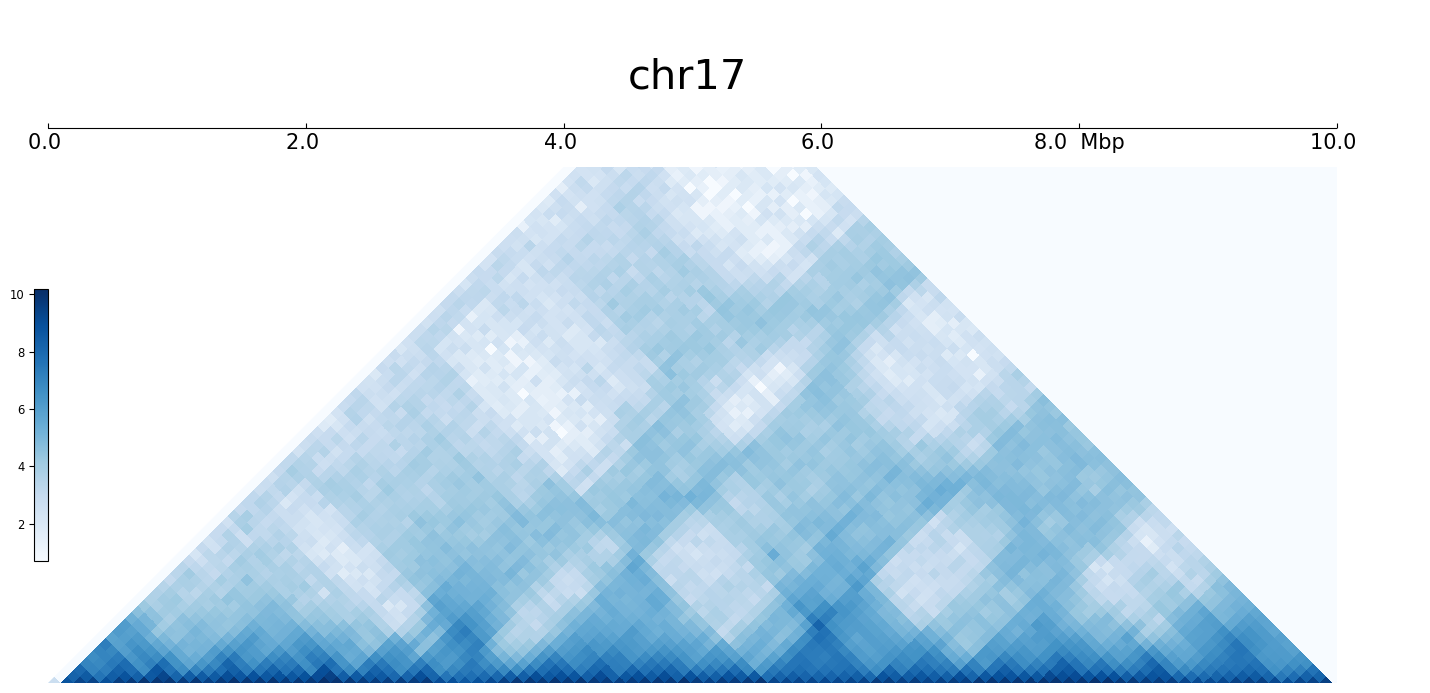

In [3]:
frame = ca.ChromName(fontsize=30) + ca.XAxis() + ha.PixelTrack(table, value_col="count", depth_ratio=0.8, cmap="Blues")
frame.goto(REGION)
frame.show()

Having to set a bunch of parameters every time you create an instance of the track can get quite tedious. For this reason HiCONA provides some subclasses of `PixelTrack`; these subclasses (named following the pattern `Pixel*`) do not override any of the logic of `PixelTrack`, they simply come with different defaults for specific applications.

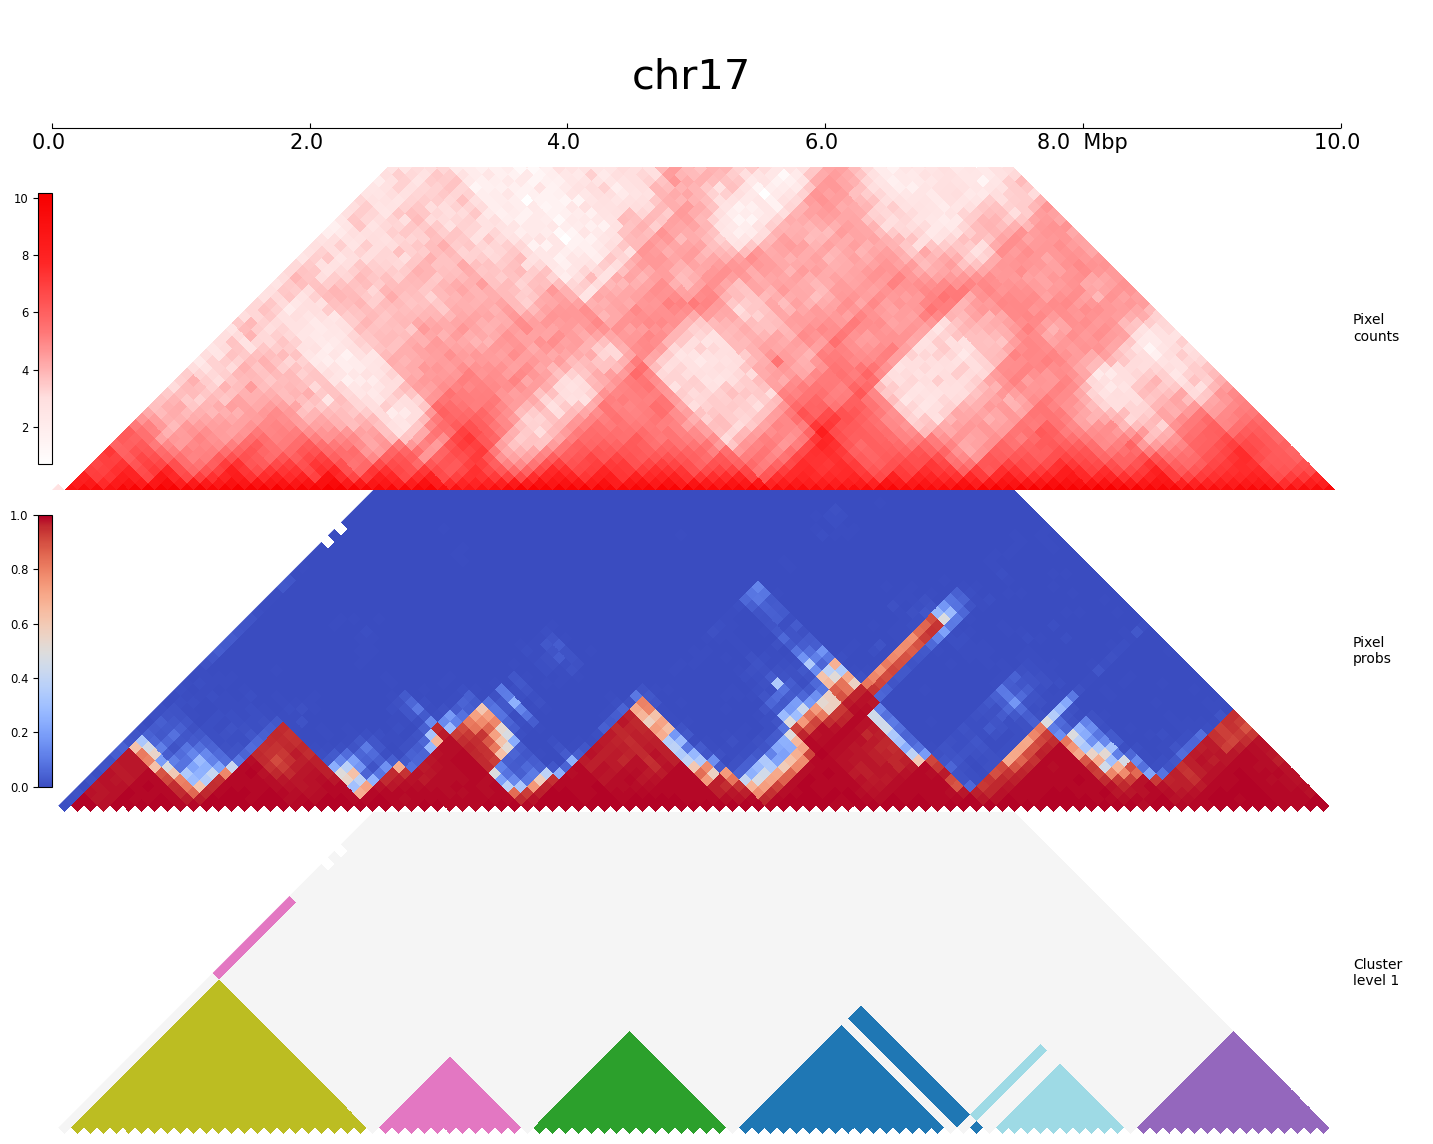

In [4]:
frame = ca.ChromName(fontsize=30) + ca.XAxis() 
frame += ha.PixelCounts(table)                       # Standard count matrix, red colormap
frame += ha.PixelProbs(table, value_col="pix_prob")  # Pixel probabilites map, blue (0) to red (1) colormap
frame += ha.PixelClusters(table, level=1)            # Pixel clustering level, arbitrary colors
frame.goto(REGION)
frame.show()

<div class="alert alert-info">

Note

If keyword arguments are passed to the subclasses, those values will override the subclass defaults for those parameters. All other subclass defaults are still used.

</div>

## Bin Tracks

The other main class introduced by HiCONA is `BinTrack`, whose instances are initialized from `PixelTable` objects. This class only implements the `fetch_data` method (which returns a slice of the `BinTable` according to the provided genomic region); for this reason, the track cannot be plotted directly and must be subclassed first to implement an appropriate `plot` method. Currently, the only subclass of `BinTrack` provided by HiCONA is `BinClusters`, which displays a level of the hierarchical clustering performed on the bins.

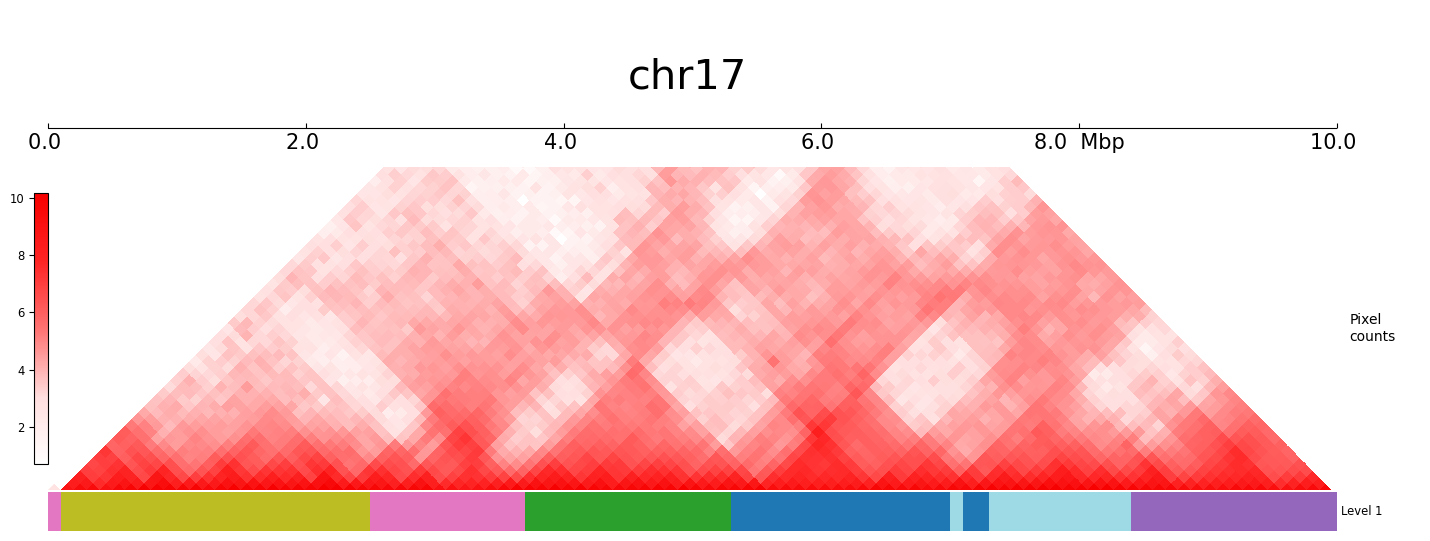

In [5]:
frame = ca.ChromName(fontsize=30) + ca.XAxis() + ha.PixelCounts(table) + ca.Spacer(0.05) + ha.BinClusters(table.bins, level=1)
frame.goto(REGION)
frame.show()

## Compatibility Tracks

At the time of writing, the way `coolbox` handles default values makes it difficult to use a [matplotlib style sheet](https://matplotlib.org/stable/users/explain/customizing.html#using-style-sheets) to style all tracks automatically. Compatibility tracks are tracks already present in `coolbox` but redefined in HiCONA with some minor changes to facilitate default styling. These tracks are used directly in HiCONA's presets of as bases for other HiCONA tracks. Only few `coolbox` track have a compatible version.

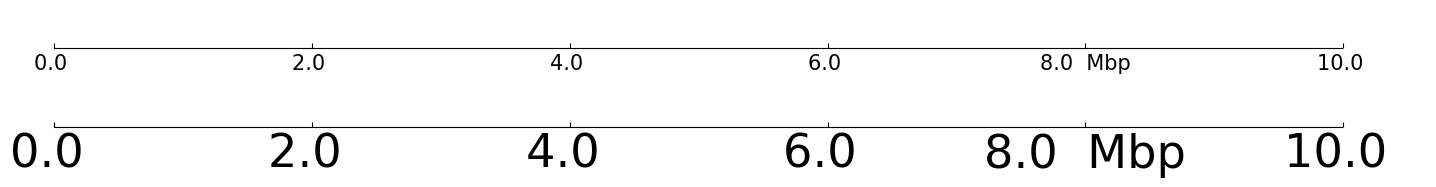

In [6]:
frame = ca.XAxis()   # Non rc compatible
frame += ha.XAxis()  # Rc compatible
frame.goto(REGION)

# Show that coolbox.XAxis ignores font size specified as an rc_param and uses default 20
with mpl.rc_context({"font.size": 40}):
    out = frame.show()
out